# Example with **DeCo**

>Tutorial author:Chenxi Wang（<sunnywcx@zju.deu.cn>）

In this tutorial, we use `LLaVA-1.5-7b` generate an image caption `DeCo`, we hope this tutorial could help you understand how to use the method DeCo on MLLMs, using the DeCo method with the LLaVA-1.5-7b as an example.

Model Hyparameters Config

In [1]:
device = "cuda"
conv_mode = "llava_v1"
model_path = "/data2/zhr/checkpoints/llava-v1.5-7b"
image_file = "/data2/zhr/datasets/val2014/COCO_val2014_000000175440.jpg"
qs = "Please describe this image in detail."
temperature = -1
top_p = None
num_beams = 1
max_new_tokens = 512

#hyparams
use_deco = True
alpha = 0.5
threshold_top_p = 0.9
threshold_top_k = 20
early_exit_layers=[i for i in range(20, 29, 1)]

In [2]:
import argparse
import torch
import os
import json
from tqdm import tqdm
import shortuuid
import sys
import os
import random
import numpy as np
os.environ["CUDA_VISIBLE_DEVICES"] = "9"
from llava.constants import (
    IMAGE_TOKEN_INDEX,
    DEFAULT_IMAGE_TOKEN,
    DEFAULT_IM_START_TOKEN,
    DEFAULT_IM_END_TOKEN,
)
from llava.conversation import conv_templates, SeparatorStyle
from llava.model.builder import load_pretrained_model
from llava.mm_utils import tokenizer_image_token, get_model_name_from_path, KeywordsStoppingCriteria
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import torch.backends.cudnn as cudnn
from llava.utils import disable_torch_init

/home/zhr/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_image(image_file):
    if image_file.startswith("http") or image_file.startswith("https"):
        response = requests.get(image_file)
        image = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        image = Image.open(image_file).convert("RGB")
    return image

def load_images(image_files):
    out = []
    for image_file in image_files:
        image = load_image(image_file)
        out.append(image)
    return out

def setup_seeds():
    seed = 927

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    cudnn.benchmark = False
    cudnn.deterministic = True

load model

In [4]:
setup_seeds()

disable_torch_init()

model_name = get_model_name_from_path(model_path)
tokenizer, model, image_processor, context_len = load_pretrained_model(model_path=model_path, 
                                                                       model_base=None, 
                                                                       model_name=model_name, 
                                                                       device=device,
                                                                       device_map=device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]/home/zhr/Deco/transformers/modeling_utils.py:460: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch

In [5]:
image_file = "/home/zhr/Deco/test.png"
# image_file = "/data2/zhr/datasets/val2014/COCO_val2014_000000226988.jpg"
qs = "Please describe this image in detail."
if model.config.mm_use_im_start_end:
    qs = DEFAULT_IM_START_TOKEN + DEFAULT_IMAGE_TOKEN + DEFAULT_IM_END_TOKEN + '\n' + qs
else:
    qs = DEFAULT_IMAGE_TOKEN + '\n' + qs

conv = conv_templates[conv_mode].copy()
conv.append_message(conv.roles[0], qs)
conv.append_message(conv.roles[1], None)
prompt = conv.get_prompt()

input_ids = tokenizer_image_token(prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors='pt').unsqueeze(0).to(device)

image = Image.open(image_file)
image_tensor = image_processor.preprocess(image, return_tensors='pt')['pixel_values'][0]
                
stop_str = conv.sep if conv.sep_style != SeparatorStyle.TWO else conv.sep2
keywords = [stop_str]
stopping_criteria = KeywordsStoppingCriteria(keywords, tokenizer, input_ids)


In [6]:
with torch.inference_mode():
    with torch.no_grad():
        ori_output_dict = model.generate(
            input_ids,
            images=image_tensor.unsqueeze(0).half().to(device),
            do_sample=True if temperature > 0 else False,
            temperature=temperature,
            top_p=top_p,
            num_beams=num_beams,
            max_new_tokens=max_new_tokens,
            # return_dict=True,
            # return_dict_in_generate=True,
            # output_hidden_states=True,
            stopping_criteria=[stopping_criteria],
        )

output_ids = ori_output_dict
input_token_len = input_ids.shape[1]
outputs = tokenizer.batch_decode(
        output_ids[:, input_token_len:], skip_special_tokens=True
    )[0]
ori_outputs = outputs.strip()

In [7]:
with torch.inference_mode():
    with torch.no_grad():
        deco_output_dict = model.generate(
            input_ids,
            images=image_tensor.unsqueeze(0).half().to(device),
            do_sample=True if temperature > 0 else False,
            temperature=temperature,
            top_p=top_p,
            num_beams=num_beams,
            max_new_tokens=max_new_tokens,
            return_dict=True,
            # return_dict_in_generate=True,
            output_hidden_states=True,
            stopping_criteria=[stopping_criteria],
            use_deco = True,
            alpha=alpha,
            threshold_top_p=threshold_top_p,
            threshold_top_k=threshold_top_k,
            early_exit_layers=early_exit_layers,
        )
        
output_ids = deco_output_dict
input_token_len = input_ids.shape[1]
outputs = tokenizer.batch_decode(
        output_ids[:, input_token_len:], skip_special_tokens=True
    )[0]
deco_outputs = outputs.strip()

In [8]:

with torch.inference_mode():
    with torch.no_grad():
        output_dict, uncond_output_dict = model.generate(
            input_ids,
            images=image_tensor.unsqueeze(0).half().to(device),
            do_sample=True if temperature > 0 else False,
            temperature=temperature,
            top_p=top_p,
            num_beams=num_beams,
            max_new_tokens=max_new_tokens,
            return_dict=True,
            return_dict_in_generate=True,
            output_hidden_states=True,
            output_scores=True,
            stopping_criteria=[stopping_criteria],
            use_uncond = True,
            alpha=alpha,
            threshold_top_p=threshold_top_p,
            threshold_top_k=threshold_top_k,
            early_exit_layers=early_exit_layers,
        )

output_ids = output_dict.sequences
input_token_len = input_ids.shape[1]
outputs = tokenizer.batch_decode(
        output_ids[:, input_token_len:], skip_special_tokens=True
    )[0]
outputs = outputs.strip()

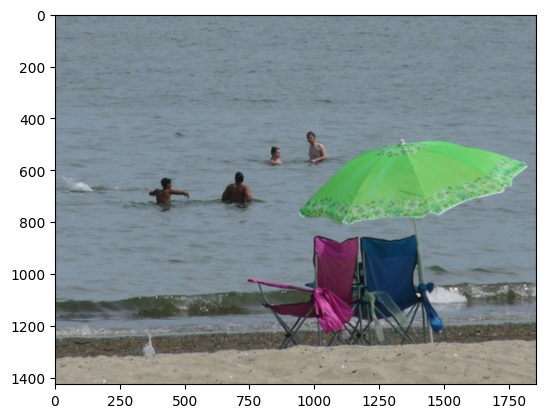

Original:
 The image features a group of people enjoying a day at the beach, with some of them swimming in the ocean. There are four people in the water, with one person closer to the left side, another in the middle, and two more towards the right side of the scene. 

A few people are standing on the beach, with one person near the left edge of the image and another person closer to the center. A chair is placed on the beach, providing a place to sit and relax. A large umbrella is set up on the beach, providing shade for the people enjoying their time by the water.


DeCo:
 The image depicts a group of people swimming in the ocean near the shore. There are four swimmers visible in the water, enjoying themselves and cooling off under the sun. They are swimming close to each other, creating a sense of camaraderie.

On the shore, there is a chair set up under an umbrella, providing shade and comfort for those who prefer to stay dry. The chair is positioned towards the right side of the s

In [9]:
plt.imshow(image)
plt.show()
print("Original:\n", ori_outputs)
print("\n")
print("DeCo:\n", deco_outputs)
print("\n")
print("Ours:\n", outputs)

Ours:
 The scene depicts a group of people swimming in the ocean near the shore. There are four swimmers visible in the water, enjoying themselves in the water. An umbrella is set up on the beach close to the water, providing a comfortable spot for beachgoers to relax. 

There are two chairs positioned near the umbrella, one on the left side and another on the right side of the umbrella. These chairs are perfect for people who want to sit down and watch the swimmers or simply enjoy the beach atmosphere.

In [17]:
outputs_tokens = output_ids[0, input_token_len:]
words = tokenizer.decode(outputs_tokens[79:]).encode("unicode_escape").decode()
print(len(outputs_tokens))
print(words)

129
 chair is situated under the umbrella, offering a comfortable spot for someone to sit and watch the beachgoers. The chair is positioned towards the right side of the umbrella, and it appears to be empty at the moment.</s>


In [18]:
token_idx = 78 # two
# token_idx = 72 # right
# token_idx = 81 # bird 

threshold_top_k = 5
probs_layers = []
uncond_probs_layers = []
hidden_states = output_dict.hidden_states[token_idx]
uncond_hidden_states = uncond_output_dict.hidden_states[token_idx]
mature_layer_idx = output_dict.selected_layers[token_idx]
uncond_layer_idx = uncond_output_dict.selected_layers[token_idx]
mature_layer_logits = -1
uncond_layer_logits = -1

for layer_id in range(0, len(hidden_states)):
    if layer_id != (len(hidden_states)-1):
        layer_output = model.model.norm(hidden_states[layer_id])
        uncond_layer_output = model.model.norm(uncond_hidden_states[layer_id])
    else:
        layer_output = hidden_states[layer_id].clone()
        uncond_layer_output = uncond_hidden_states[layer_id].clone()
    logits = model.lm_head(layer_output)[:,-1,:]
    uncond_logits = model.lm_head(uncond_layer_output)[:,-1,:]
    if layer_id == mature_layer_idx:
        mature_layer_logits = logits
    if layer_id == uncond_layer_idx:
        uncond_layer_logits = uncond_logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    uncond_probs = torch.nn.functional.softmax(uncond_logits, dim=-1)
    probs_layers.append(probs)
    uncond_probs_layers.append(uncond_probs)

probs = torch.cat([probs.data for probs in probs_layers])
uncond_probs = torch.cat([probs.data for probs in uncond_probs_layers])

In [20]:

candidate_tokens_probs, candidate_tokens_ids = torch.topk(probs[-1], dim=-1, k=threshold_top_k)

candidate_tokens_cumulative_probs = candidate_tokens_probs.cumsum(dim=-1)
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, threshold_top_p, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))    

final_softmax_score = torch.nn.functional.softmax(output_dict.scores[token_idx][0], dim=-1)
final_tokens_probs, final_tokens_ids = torch.topk(final_softmax_score, dim=-1, k=threshold_top_k)

candidate_tokens_early_exit_probs = probs[:,candidate_tokens_ids]
uncond_candidate_tokens_early_exit_probs = uncond_probs[:,candidate_tokens_ids]

words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in candidate_tokens_ids]

final_words = [tokenizer.decode(t.cpu()).encode("unicode_escape").decode() for t in final_tokens_ids]

print("candidate_tokens\n", words)
print(candidate_tokens_probs)

print("top_p_candidate_tokens\n", words[:candidate_tokens_cutoff_idx])
print(candidate_tokens_probs[:candidate_tokens_cutoff_idx])

print("final_tokens\n", final_words)
print(final_tokens_probs)


candidate_tokens
 ['A', 'The', 'Two', 'There', 'An']
tensor([0.4019, 0.2052, 0.0779, 0.0472, 0.0335], device='cuda:0',
       dtype=torch.float16)
top_p_candidate_tokens
 ['A', 'The', 'Two', 'There', 'An']
tensor([0.4019, 0.2052, 0.0779, 0.0472, 0.0335], device='cuda:0',
       dtype=torch.float16)
final_tokens
 ['A', 'The', 'Two', 'There', 'An']
tensor([0.4432, 0.2484, 0.0817, 0.0424, 0.0408], device='cuda:0')


Selected mature layer: 28
premature_max_probs: 0.224365234375
Selected mature layer logits: tensor([[4.1680, 5.3281, 8.5625, 9.3984, 5.8672]], device='cuda:0',
       dtype=torch.float16, grad_fn=<IndexBackward0>)


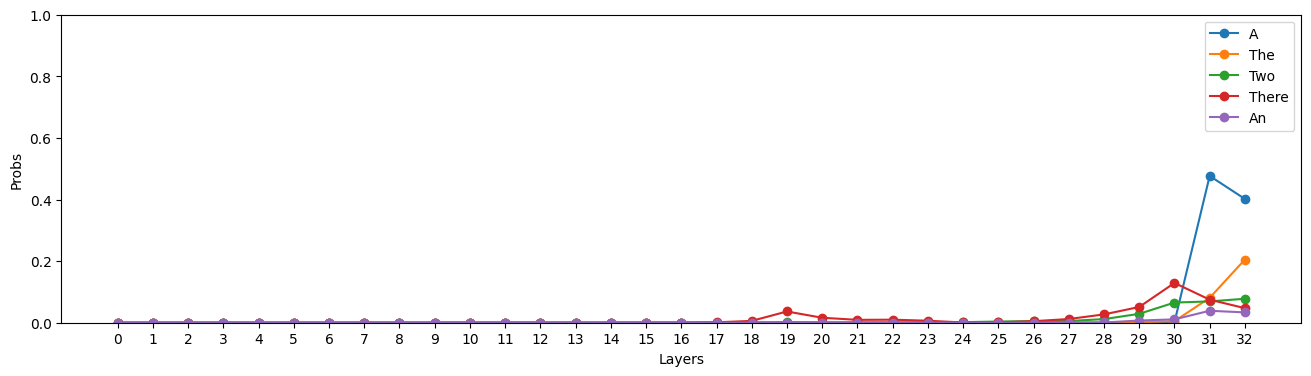

In [21]:
print("Selected mature layer:", mature_layer_idx)
print("premature_max_probs:", probs[mature_layer_idx].max().item())
print("Selected mature layer logits:", mature_layer_logits[:, candidate_tokens_ids])
plt.figure(figsize=(16, 4))
plt.plot(candidate_tokens_early_exit_probs.cpu().numpy(), marker = 'o')
plt.xlabel("Layers")
plt.ylabel("Probs")
plt.xticks(range(33))
plt.ylim(0,1)
plt.legend(words)
plt.show()


Selected uncond layer: 32
uncond_max_probs: 0.1719970703125
Selected uncond layer logits: tensor([[19.9375, 18.3438, 18.7969, 19.8594, 16.4531]], device='cuda:0',
       dtype=torch.float16, grad_fn=<IndexBackward0>)


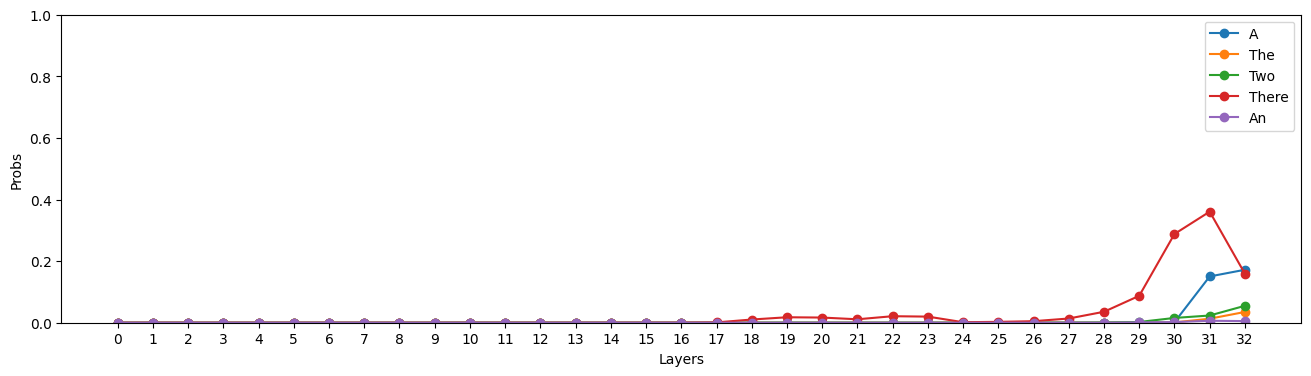

In [22]:
print("Selected uncond layer:", uncond_layer_idx)
print("uncond_max_probs:", uncond_probs[uncond_layer_idx].max().item())
print("Selected uncond layer logits:", uncond_layer_logits[:, candidate_tokens_ids])
plt.figure(figsize=(16, 4))
plt.plot(uncond_candidate_tokens_early_exit_probs.cpu().numpy(), marker = 'o')
plt.xlabel("Layers")
plt.ylabel("Probs")
plt.xticks(range(33))
plt.ylim(0,1)
plt.legend(words)
plt.show()